# Notebook 01_01 — Fine-tune PhoBERT with class weights

Same data and split as notebook 01. Difference: **weighted cross-entropy** so minority `positive` / `negative` cost more than majority `neutral`.

**Why:** val in 01 dumps polar comments into neutral (neg recall 0.38, neu 0.91). Unweighted CE + 55% neu.

**Input:** train/val split from notebook 00  
**Output:** `model/artifacts/phobert_weighted/` (does **not** overwrite the 01 model)

Run cells 1–5 + **readiness check** first. Then run **full training** yourself (~15–45 min/epoch on CPU).

**Success:** macro-F1 vs 01 (0.66) and smaller true-pos/neg → predicted-neu cells. Accuracy may drop — ignore it.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from pyvi.ViTokenizer import tokenize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif not (PROJECT_ROOT / "model" / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from model.config import ARTIFACTS_DIR, LABELED_CSV_PATH, SPLIT_INDICES_PATH

MODEL_NAME = "vinai/phobert-base"
MAX_LENGTH = 128
NUM_EPOCHS = 5
BATCH_SIZE = 8
LEARNING_RATE = 2e-5

# Separate dir so notebook 01 artifacts stay.
OUTPUT_DIR = ARTIFACTS_DIR / "phobert_weighted"

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")
print(f"Model:  {MODEL_NAME}")
print(f"Out:    {OUTPUT_DIR}")

Device: mps
Model:  vinai/phobert-base
Out:    /Users/pdc/PycharmProjects/matgrouptest/model/artifacts/phobert_weighted


## 1. Load train/val split + class weights

`balanced` weight = `n_samples / (n_classes * n_class)`. Rare class → bigger weight → bigger loss if wrong.

In [2]:
with SPLIT_INDICES_PATH.open(encoding="utf-8") as f:
    split = json.load(f)

df = pd.read_csv(LABELED_CSV_PATH)
train_df = df.loc[split["train_indices"]].reset_index(drop=True)
val_df = df.loc[split["val_indices"]].reset_index(drop=True)

print(f"Train: {len(train_df)}  Val: {len(val_df)}")
print("Train counts:")
print(train_df["sentiment"].value_counts().reindex(["negative", "neutral", "positive"]))

y_train = train_df["sentiment"].map(LABEL2ID).to_numpy()
weight_values = compute_class_weight(
    "balanced",
    classes=np.array([0, 1, 2]),
    y=y_train,
)
CLASS_WEIGHTS = torch.tensor(weight_values, dtype=torch.float)

print("\nClass weights (id → name → weight):")
for i, w in enumerate(weight_values):
    print(f"  {i}  {ID2LABEL[i]:8s}  {w:.3f}")

Train: 799  Val: 200
Train counts:
sentiment
negative    197
neutral     420
positive    182
Name: count, dtype: int64

Class weights (id → name → weight):
  0  negative  1.352
  1  neutral   0.634
  2  positive  1.463


## 2. Load pretrained PhoBERT + label map

Downloads `vinai/phobert-base` from Hugging Face on first run (~500MB, cached locally).

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
label_map_path = OUTPUT_DIR / "label_map.json"
with label_map_path.open("w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in ID2LABEL.items()}, f, indent=2, ensure_ascii=False)

print("Label map:", ID2LABEL)
print(f"Saved: {label_map_path}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Label map: {0: 'negative', 1: 'neutral', 2: 'positive'}
Saved: /Users/pdc/PycharmProjects/matgrouptest/model/artifacts/phobert_weighted/label_map.json


## 3. Preprocess & tokenize

Whitespace normalized, diacritics kept, `pyvi` word segmentation before PhoBERT tokenize.

In [4]:
import re

ABBREV_MAP = {
    "ko": "không",
    "k": "không",
    "kh": "không",
    "hong": "không",
    "dc": "được",
    "đc": "được",
    "duoc": "được",
    "vs": "với",
    "j": "gì",
    "ns": "nói",
    "bn": "bạn",
    "ng": "người",
}
ABBREV_PATTERN = re.compile(
    r"\\b(" + "|".join(re.escape(k) for k in sorted(ABBREV_MAP, key=len, reverse=True)) + r")\\b",
    flags=re.IGNORECASE,
)


def expand_abbrev(text: str) -> str:
    # ponytail: skip ambiguous keys like "bt" to avoid wrong replacements.
    return ABBREV_PATTERN.sub(lambda m: ABBREV_MAP[m.group(0).lower()], text)


def preprocess(text: str) -> str:
    normalized = " ".join(str(text).split())
    normalized = expand_abbrev(normalized)
    return tokenize(normalized)


class CommentDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["comment"].tolist()
        self.labels = [LABEL2ID[s] for s in frame["sentiment"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = tokenizer(
            preprocess(self.texts[idx]),
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
        )
        item = {k: torch.tensor(v) for k, v in encoded.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = CommentDataset(train_df)
val_dataset = CommentDataset(val_df)

sample = train_dataset[0]
print("Sample keys:", list(sample.keys()))
print("input_ids shape:", sample["input_ids"].shape)

Sample keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([128])


## 4. Weighted Trainer

Default `Trainer` uses unweighted CE. Override `compute_loss` with `CLASS_WEIGHTS` from cell 1.

In [5]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
    }


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits,
            labels,
            weight=CLASS_WEIGHTS.to(outputs.logits.device),
        )
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=20,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Weighted Trainer ready.")

Weighted Trainer ready.


## 5. Readiness check

One training step on 4 samples — confirms model download, tokenize, MPS/CPU, **weighted loss** all work. **Not real training.**

In [6]:
from torch.utils.data import Subset

smoke_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "smoke"),
    max_steps=1,
    per_device_train_batch_size=2,
    learning_rate=LEARNING_RATE,
    report_to="none",
)

smoke_trainer = WeightedTrainer(
    model=model,
    args=smoke_args,
    train_dataset=Subset(train_dataset, range(4)),
)

smoke_trainer.train()
print("OK — ready for full training. Run the next cell when you are.")

/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


OK — ready for full training. Run the next cell when you are.


## 6. Full training — **run this yourself**

Expect ~15–45 min/epoch on CPU, faster on Apple MPS. Early stopping may finish before 5 epochs.

In [7]:
trainer.train()

/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.059900,1.041785,0.495000,0.448673
2,0.903400,0.905620,0.635000,0.612666
3,0.777800,0.797435,0.705000,0.685515
4,0.597300,0.775847,0.635000,0.630188
5,0.495500,0.786468,0.700000,0.678257


/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super()._

TrainOutput(global_step=500, training_loss=0.7890427532196045, metrics={'train_runtime': 326.2245, 'train_samples_per_second': 12.246, 'train_steps_per_second': 1.533, 'total_flos': 262784525955840.0, 'train_loss': 0.7890427532196045, 'epoch': 5.0})

## 7. Training curves

Run after full training completes.

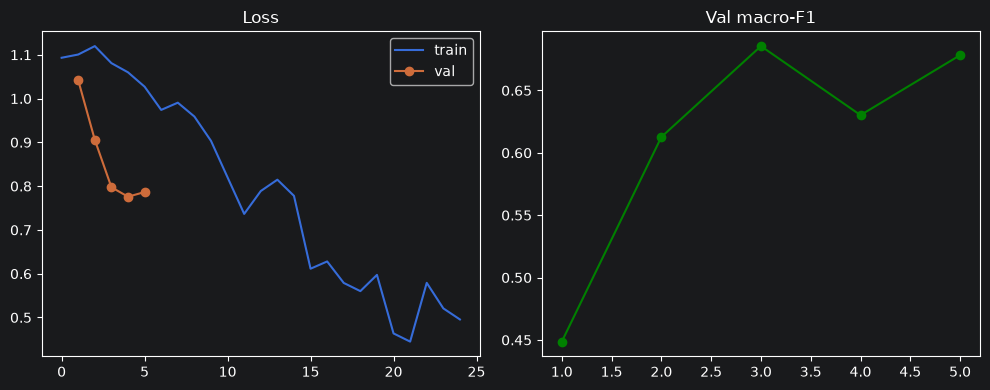

In [8]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
eval_epochs = [x for x in history if "eval_loss" in x]
if not eval_epochs:
    print("Skip — run full training (cell 6) first, then re-run cells below.")
else:
    train_loss = [x["loss"] for x in history if "loss" in x]
    eval_loss = [x["eval_loss"] for x in eval_epochs]
    eval_f1 = [x["eval_f1"] for x in eval_epochs if "eval_f1" in x]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_loss, label="train")
    axes[0].plot(range(1, len(eval_loss) + 1), eval_loss, marker="o", label="val")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(range(1, len(eval_f1) + 1), eval_f1, marker="o", color="green")
    axes[1].set_title("Val macro-F1")
    plt.tight_layout()
    plt.show()

## 8. Evaluate on validation set

Compare to notebook 01: neg recall 0.38 / neu 0.91 / pos 0.64, macro-F1 0.66. Weighted run should lift polar recall; neu recall can fall.

/Users/pdc/PycharmProjects/matgrouptest/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.58      0.64      0.61        50
     neutral       0.80      0.73      0.77       105
    positive       0.65      0.71      0.68        45

    accuracy                           0.70       200
   macro avg       0.68      0.69      0.69       200
weighted avg       0.71      0.70      0.71       200

Notebook 01 baseline — neg 0.38 / neu 0.91 / pos 0.64 recall, macro-F1 0.66


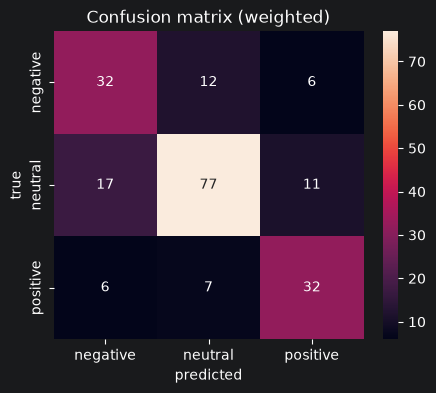

In [9]:
import seaborn as sns

if not [x for x in trainer.state.log_history if "eval_loss" in x]:
    print("Skip — run full training first.")
else:
    preds = trainer.predict(val_dataset)
    y_true = preds.label_ids
    y_pred = np.argmax(preds.predictions, axis=-1)
    target_names = [ID2LABEL[i] for i in range(3)]

    print(classification_report(y_true, y_pred, target_names=target_names))
    print("Notebook 01 baseline — neg 0.38 / neu 0.91 / pos 0.64 recall, macro-F1 0.66")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.title("Confusion matrix (weighted)")
    plt.show()

## 9. Sample predictions (5 correct + 5 wrong)

In [10]:
if "y_pred" not in globals():
    print("Skip — run evaluate cell first.")
else:
    results = val_df.copy()
    results["pred"] = [ID2LABEL[p] for p in y_pred]
    results["correct"] = results["sentiment"] == results["pred"]

    print("=== 5 correct ===")
    display(results.loc[results["correct"], ["comment", "sentiment", "pred"]].head(5))

    print("=== 5 wrong ===")
    display(results.loc[~results["correct"], ["comment", "sentiment", "pred"]].head(5))

=== 5 correct ===


,comment,sentiment,pred
0,khách mời vui tính dễ thương quá.,positive,positive
1,​ Bác ở chung cư à😂. Ở nhà đất có gara thì sạ...,neutral,neutral
2,"nhanh thế, full đen đẹp quá nhỉ, xúc",positive,positive
3,Tipcar ko lòng vòng vào vấn đề nhanh gọn công tâm,positive,positive
4,"Mình rất thích nội thất màu nâu, ghi, kem",positive,positive


=== 5 wrong ===


,comment,sentiment,pred
8,Tôi đang đi Lexus 470 hơn 10 đăng ký Vf9 ngày ...,positive,neutral
10,Bác ns rất đúng. Chính vì e đọc comment người ...,neutral,negative
21,"Ồn từ lốp lên xử lý dễ ợt à, tráng lốp rồi dán...",neutral,negative
22,chờ độ hoàn thiện tăng lên và giá về đúng giá trị,negative,positive
26,Chắc mua BYD 😂,negative,neutral


## 10. Export model

Writes to `model/artifacts/phobert_weighted/`. API still uses `phobert/` until you copy or change `MODEL_PATH`.

In [11]:
if not [x for x in trainer.state.log_history if "eval_loss" in x]:
    print("Skip — run full training first.")
else:
    trainer.save_model(str(OUTPUT_DIR))
    tokenizer.save_pretrained(str(OUTPUT_DIR))
    print(f"Exported to {OUTPUT_DIR}")

Exported to /Users/pdc/PycharmProjects/matgrouptest/model/artifacts/phobert_weighted
